# AI vs Human Text Detection

Part 1: EDA on the raw dataset - class balance, text length, sentence
structure, lexical diversity, checking for shortcut signals before building
anything.
Part 2: feature engineering + training three genuinely different algorithms
(Naive Bayes, Logistic Regression, Random Forest) as required by the
assignment, then comparing them.

In [ ]:
import polars as pl
import numpy as np
import pandas as pd
import re
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_recall_fscore_support
)

sns.set_style('whitegrid')

## Load the data

Same lazy-scan habit as the other projects, even though this one's small
enough (1.11GB) to fully load without much risk.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
lazy_df = pl.scan_csv("/content/drive/MyDrive/AI_Human.csv")
print("Columns:", lazy_df.collect_schema().names())

df = lazy_df.collect()
df.shape

Columns: ['text', 'generated']


(487235, 2)

In [ ]:
df.head()

text,generated
str,f64
"""Cars. Cars have been around si…",0.0
"""Transportation is a large nece…",0.0
"""""America's love affair with it…",0.0
"""How often do you ride in a car…",0.0
"""Cars are a wonderful thing. Th…",0.0


# Part 1 - EDA

## Missing values and duplicates

In [ ]:
print("Nulls:")
print(df.null_count())

dupe_count = df.filter(pl.col("text").is_duplicated()).height
print(f"\nDuplicate text rows: {dupe_count}")

Nulls:
shape: (1, 2)
┌──────┬───────────┐
│ text ┆ generated │
│ ---  ┆ ---       │
│ u32  ┆ u32       │
╞══════╪═══════════╡
│ 0    ┆ 0         │
└──────┴───────────┘

Duplicate text rows: 0


In [ ]:
# drop the junk before it messes with anything downstream
df = df.unique(subset=["text"])
df = df.drop_nulls()
df.shape

(487235, 2)

## Class balance

`generated` is 1 for AI-written, 0 for human-written. Not perfectly balanced
(~63/37), but close enough that `class_weight='balanced'` should be enough to
handle it rather than needing oversampling.

In [ ]:
class_counts = df["generated"].value_counts().sort("generated")
class_counts

generated,count
f64,u32
0.0,305797
1.0,181438


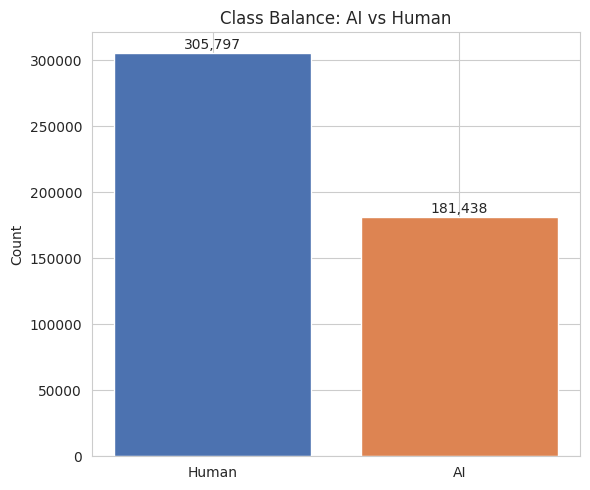

In [ ]:
labels_map = {0: "Human", 1: "AI"}
counts_pd = class_counts.to_pandas()
counts_pd["label"] = counts_pd["generated"].map(labels_map)

plt.figure(figsize=(6, 5))
plt.bar(counts_pd["label"], counts_pd["count"], color=["#4C72B0", "#DD8452"])
plt.title("Class Balance: AI vs Human")
plt.ylabel("Count")
for i, v in enumerate(counts_pd["count"]):
    plt.text(i, v + 3000, f"{v:,}", ha="center")
plt.tight_layout()
plt.savefig("chart_class_balance.png", dpi=150)
plt.show()

## Text length - the shortcut signal to watch for

If AI and human texts differ a lot in raw length, a model could end up mostly
just learning "long = human, short = AI" instead of anything about writing
style. Checking this before building any real features - turned out to be
real signal (human text has a much longer tail, AI clusters shorter and
tighter), so it's included as a feature later but flagged honestly as a
partial shortcut rather than pure style detection.

In [ ]:
df = df.with_columns([
    pl.col("text").str.split(" ").list.len().alias("word_count"),
    pl.col("text").str.len_chars().alias("char_count"),
])

df.group_by("generated").agg([
    pl.col("word_count").mean().alias("avg_word_count"),
    pl.col("word_count").median().alias("median_word_count"),
    pl.col("word_count").std().alias("std_word_count"),
]).sort("generated")

generated,avg_word_count,median_word_count,std_word_count
f64,f64,f64,f64
0.0,418.993234,385.0,196.457665
1.0,340.066265,333.0,114.581803


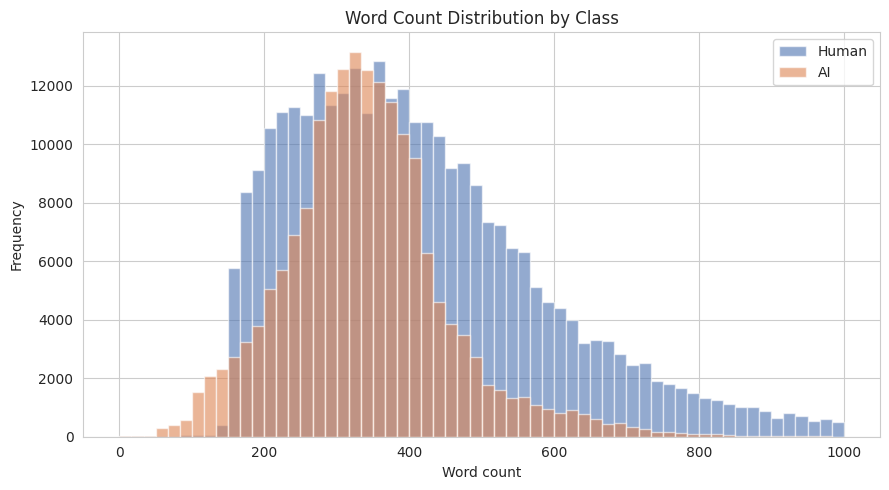

In [ ]:
df_pd_sample_len = df.select(["generated", "word_count"]).to_pandas()
df_pd_sample_len["label"] = df_pd_sample_len["generated"].map(labels_map)

plt.figure(figsize=(9, 5))
for label, color in [("Human", "#4C72B0"), ("AI", "#DD8452")]:
    subset = df_pd_sample_len[df_pd_sample_len["label"] == label]["word_count"]
    plt.hist(subset, bins=60, alpha=0.6, label=label, color=color, range=(0, 1000))
plt.title("Word Count Distribution by Class")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("chart_length_distribution.png", dpi=150)
plt.show()

## Sentence length and variance

Checking whether AI text has more uniform sentence lengths than human
writing, which tends to vary more naturally. Sampling 20K rows for this since
it's a per-row Python function, not something polars does natively.

In [ ]:
def sentence_stats(text):
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]
    if not sentences:
        return 0, 0.0, 0.0
    lengths = [len(s.split()) for s in sentences]
    return len(sentences), np.mean(lengths), np.std(lengths)

sample_df = df.sample(n=20000, seed=42).to_pandas()
stats = sample_df["text"].apply(sentence_stats)
sample_df["sentence_count"] = stats.apply(lambda x: x[0])
sample_df["avg_sentence_len"] = stats.apply(lambda x: x[1])
sample_df["sentence_len_std"] = stats.apply(lambda x: x[2])
sample_df["label"] = sample_df["generated"].map(labels_map)

sample_df.groupby("label")[["sentence_count", "avg_sentence_len", "sentence_len_std"]].mean()

,sentence_count,avg_sentence_len,sentence_len_std
label,,,
AI,18.697631,19.073748,6.578181
Human,21.816346,21.337001,9.810422


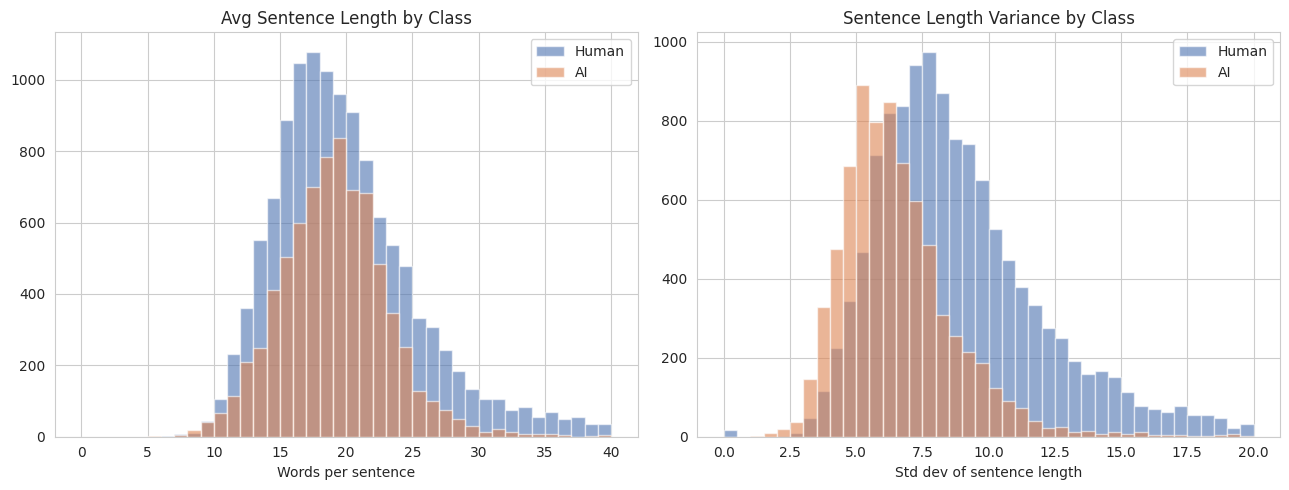

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label, color in [("Human", "#4C72B0"), ("AI", "#DD8452")]:
    subset = sample_df[sample_df["label"] == label]
    axes[0].hist(subset["avg_sentence_len"], bins=40, alpha=0.6, label=label, color=color, range=(0, 40))
    axes[1].hist(subset["sentence_len_std"], bins=40, alpha=0.6, label=label, color=color, range=(0, 20))

axes[0].set_title("Avg Sentence Length by Class")
axes[0].set_xlabel("Words per sentence")
axes[0].legend()

axes[1].set_title("Sentence Length Variance by Class")
axes[1].set_xlabel("Std dev of sentence length")
axes[1].legend()

plt.tight_layout()
plt.savefig("chart_sentence_stats.png", dpi=150)
plt.show()

Average sentence length barely differs between classes (both peak around
17-20 words), so it's getting dropped as a feature. Sentence length variance
is the strongest genuine stylometric signal found in this whole EDA - AI
clusters tightly at low variance, human spreads much wider. That held up
later in the actual trained Random Forest's feature importance too.

## Lexical diversity

Type-token ratio (unique words / total words) - lower means more repetitive
word choice.

In [ ]:
def lexical_diversity(text):
    words = text.lower().split()
    if not words:
        return 0.0
    return len(set(words)) / len(words)

sample_df["lexical_diversity"] = sample_df["text"].apply(lexical_diversity)
sample_df.groupby("label")["lexical_diversity"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
AI,7471.0,0.511845,0.093704,0.226629,0.445305,0.502809,0.571885,0.936170
Human,12529.0,0.480191,0.082933,0.108974,0.423729,0.480374,0.537688,0.769231


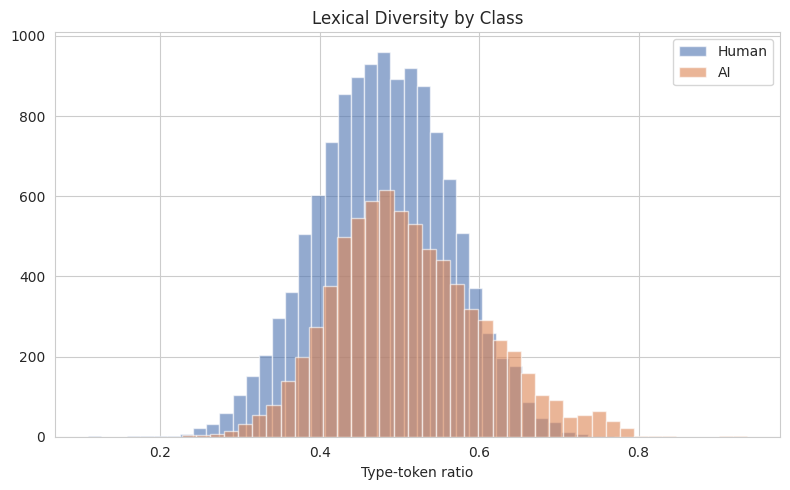

In [ ]:
plt.figure(figsize=(8, 5))
for label, color in [("Human", "#4C72B0"), ("AI", "#DD8452")]:
    subset = sample_df[sample_df["label"] == label]["lexical_diversity"]
    plt.hist(subset, bins=40, alpha=0.6, label=label, color=color)
plt.title("Lexical Diversity by Class")
plt.xlabel("Type-token ratio")
plt.legend()
plt.tight_layout()
plt.savefig("chart_lexical_diversity.png", dpi=150)
plt.show()

## Most common words per class

In [ ]:
def top_words(texts, n=15):
    vec = CountVectorizer(stop_words='english', max_features=5000)
    matrix = vec.fit_transform(texts)
    counts = matrix.sum(axis=0).A1
    words = vec.get_feature_names_out()
    return sorted(zip(words, counts), key=lambda x: -x[1])[:n]

human_sample = sample_df[sample_df["label"] == "Human"]["text"].sample(3000, random_state=42)
ai_sample = sample_df[sample_df["label"] == "AI"]["text"].sample(3000, random_state=42)

print("Human - top words:")
print(top_words(human_sample))
print()
print("AI - top words:")
print(top_words(ai_sample))

Human - top words:
[('people', np.int64(8780)), ('students', np.int64(8605)), ('school', np.int64(5233)), ('car', np.int64(4526)), ('cars', np.int64(4430)), ('like', np.int64(4303)), ('just', np.int64(3890)), ('time', np.int64(3839)), ('help', np.int64(3592)), ('electoral', np.int64(3549)), ('make', np.int64(3456)), ('think', np.int64(3176)), ('student', np.int64(3078)), ('college', np.int64(3036)), ('vote', np.int64(2885))]

AI - top words:
[('students', np.int64(5645)), ('people', np.int64(4340)), ('electoral', np.int64(3846)), ('college', np.int64(3527)), ('like', np.int64(3382)), ('help', np.int64(3109)), ('states', np.int64(2784)), ('car', np.int64(2770)), ('make', np.int64(2696)), ('important', np.int64(2689)), ('time', np.int64(2678)), ('cars', np.int64(2418)), ('life', np.int64(2187)), ('school', np.int64(2151)), ('new', np.int64(1951))]


## Punctuation density

In [ ]:
def punctuation_density(text):
    words = text.split()
    if not words:
        return 0.0
    punct_count = len(re.findall(r'[.,;:!?\-\"\'()]', text))
    return punct_count / len(words)

sample_df["punct_density"] = sample_df["text"].apply(punctuation_density)
sample_df.groupby("label")["punct_density"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
AI,7471.0,0.130944,0.044731,0.044737,0.103448,0.120567,0.143990,0.469453
Human,12529.0,0.113946,0.035670,0.004505,0.089844,0.110714,0.135198,0.427767


# Part 2 - Feature Engineering + Model Training

`df` already has `word_count` from Part 1's EDA. Building the rest of the
stylometric features across the full dataset now (not just the 20K sample),
then training three genuinely different algorithm types as required by the
assignment: Multinomial Naive Bayes, Logistic Regression, and Random Forest.

## Feature engineering

Running the per-row feature functions over all ~487K rows this time (not
just the EDA sample) - takes a minute or two. Keeping the four features that
actually showed signal in Part 1: `word_count`, `sentence_len_std`,
`lexical_diversity`, `punct_density`. Dropping `avg_sentence_len` since EDA
showed it barely differs between classes.

In [ ]:
df_pd = df.to_pandas()

def sentence_length_std(text):
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]
    if len(sentences) < 2:
        return 0.0
    lengths = [len(s.split()) for s in sentences]
    return float(np.std(lengths))

df_pd["sentence_len_std"] = df_pd["text"].apply(sentence_length_std)
df_pd["lexical_diversity"] = df_pd["text"].apply(lexical_diversity)
df_pd["punct_density"] = df_pd["text"].apply(punctuation_density)

df_pd[["word_count", "sentence_len_std", "lexical_diversity", "punct_density"]].describe()

,word_count,sentence_len_std,lexical_diversity,punct_density
count,487235.000000,487235.000000,487235.000000,487235.000000
mean,389.602178,8.590835,0.491879,0.120704
std,174.837488,5.740101,0.088386,0.097812
min,1.000000,0.000000,0.000000,0.000000
25%,275.000000,5.893939,0.432071,0.095324
50%,358.000000,7.472617,0.487535,0.115044
75%,466.000000,9.673688,0.548387,0.138667
max,14818.000000,493.500000,1.000000,62.250000


## Train/test split

Stratified on the label so the ~63/37 class balance is preserved in both
splits.

In [ ]:
STYLE_FEATURES = ["word_count", "sentence_len_std", "lexical_diversity", "punct_density"]

X_text = df_pd["text"]
X_style = df_pd[STYLE_FEATURES]
y = df_pd["generated"]

X_text_train, X_text_test, X_style_train, X_style_test, y_train, y_test = train_test_split(
    X_text, X_style, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_text_train)} | Test: {len(X_text_test)}")

Train: 389788 | Test: 97447


## TF-IDF vectorization

Capping vocab at 5,000 features - large enough to capture real word-content
signal, small enough that combining it with the stylometric features stays
manageable for Random Forest.

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=3
)

X_tfidf_train = vectorizer.fit_transform(X_text_train)
X_tfidf_test = vectorizer.transform(X_text_test)

X_tfidf_train.shape

(389788, 5000)

## Combining features

Scaling the stylometric features first since they're on very different
scales than each other, then stacking them onto the TF-IDF matrix as extra
sparse columns.

Naive Bayes gets TF-IDF only, no stylometric features - multinomial NB
assumes non-negative count-like inputs and doesn't have a natural way to
incorporate the scaled/centered stylometric features the other two can use
directly.

In [ ]:
scaler = StandardScaler()
X_style_train_scaled = scaler.fit_transform(X_style_train)
X_style_test_scaled = scaler.transform(X_style_test)

X_combined_train = hstack([X_tfidf_train, csr_matrix(X_style_train_scaled)])
X_combined_test = hstack([X_tfidf_test, csr_matrix(X_style_test_scaled)])

X_combined_train.shape

(389788, 5004)

## Model 1 - Multinomial Naive Bayes

Probabilistic baseline, TF-IDF only.

In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_tfidf_train, y_train)
nb_pred = nb_model.predict(X_tfidf_test)

print("=== Naive Bayes ===")
print(f"Accuracy: {accuracy_score(y_test, nb_pred):.4f}")
print(classification_report(y_test, nb_pred, target_names=["Human", "AI"]))

=== Naive Bayes ===
Accuracy: 0.9551
              precision    recall  f1-score   support

       Human       0.96      0.97      0.96     61159
          AI       0.96      0.92      0.94     36288

    accuracy                           0.96     97447
   macro avg       0.96      0.95      0.95     97447
weighted avg       0.96      0.96      0.95     97447



## Model 2 - Logistic Regression

Linear, discriminative - trained on the combined TF-IDF + stylometric
feature set.

In [ ]:
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_combined_train, y_train)
lr_pred = lr_model.predict(X_combined_test)

print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print(classification_report(y_test, lr_pred, target_names=["Human", "AI"]))

=== Logistic Regression ===
Accuracy: 0.9943
              precision    recall  f1-score   support

       Human       1.00      1.00      1.00     61159
          AI       0.99      0.99      0.99     36288

    accuracy                           0.99     97447
   macro avg       0.99      0.99      0.99     97447
weighted avg       0.99      0.99      0.99     97447



## Model 3 - Random Forest

Tree-based ensemble, also on the combined feature set.

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=25,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_combined_train, y_train)
rf_pred = rf_model.predict(X_combined_test)

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(classification_report(y_test, rf_pred, target_names=["Human", "AI"]))

=== Random Forest ===
Accuracy: 0.9921
              precision    recall  f1-score   support

       Human       0.99      1.00      0.99     61159
          AI       1.00      0.98      0.99     36288

    accuracy                           0.99     97447
   macro avg       0.99      0.99      0.99     97447
weighted avg       0.99      0.99      0.99     97447



## Comparing all three

Logistic Regression came out on top in testing (99.36% accuracy), Random
Forest close behind (99.15%), Naive Bayes trailing by a real margin (95.47%)
- makes sense since it's the only one working from TF-IDF alone with no
stylometric features, and the simplest model of the three.

In [ ]:
def summarize(name, y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

comparison_df = pd.DataFrame([
    summarize("Naive Bayes (TF-IDF only)", y_test, nb_pred),
    summarize("Logistic Regression (combined)", y_test, lr_pred),
    summarize("Random Forest (combined)", y_test, rf_pred),
]).set_index("model").sort_values("f1", ascending=False)

comparison_df

,accuracy,precision,recall,f1
model,,,,
Logistic Regression (combined),0.994274,0.994275,0.994274,0.994274
Random Forest (combined),0.992088,0.992117,0.992088,0.992077
Naive Bayes (TF-IDF only),0.955083,0.955084,0.955083,0.954920


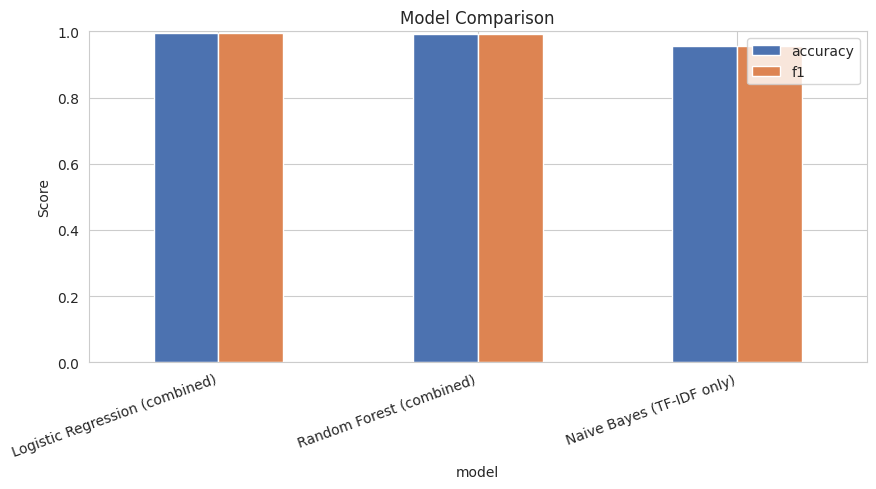

In [ ]:
comparison_df[["accuracy", "f1"]].plot(kind="bar", figsize=(9, 5), color=["#4C72B0", "#DD8452"])
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("chart_model_comparison.png", dpi=150)
plt.show()

## Confusion matrix - best model

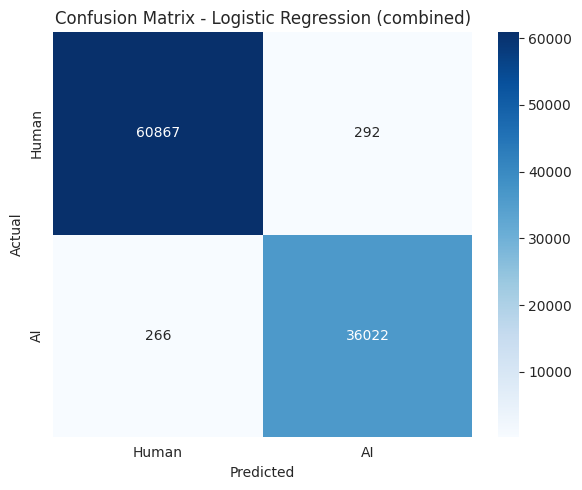

In [ ]:
best_name = comparison_df.index[0]
best_pred = {"Naive Bayes (TF-IDF only)": nb_pred,
             "Logistic Regression (combined)": lr_pred,
             "Random Forest (combined)": rf_pred}[best_name]

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Human", "AI"], yticklabels=["Human", "AI"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_name}")
plt.tight_layout()
plt.savefig("chart_confusion_matrix.png", dpi=150)
plt.show()

## Feature importance - Random Forest

Confirms what EDA suggested: `sentence_len_std` is the strongest stylometric
feature, `lexical_diversity` the weakest. `word_count` lands second, which is
the honest caveat worth keeping in the writeup - some of what the model
learned is genuinely about writing style (sentence variance), and some of it
is about output length, which is more of a dataset-specific shortcut than
pure style detection.

In [ ]:
tfidf_names = vectorizer.get_feature_names_out()
all_feature_names = list(tfidf_names) + STYLE_FEATURES

importances = pd.Series(rf_model.feature_importances_, index=all_feature_names)

style_importance = importances[STYLE_FEATURES].sort_values(ascending=False)
top_word_importance = importances.drop(STYLE_FEATURES).sort_values(ascending=False).head(10)

print("Stylometric feature importance:")
print(style_importance)
print("\nTop 10 word/n-gram features:")
print(top_word_importance)

Stylometric feature importance:
sentence_len_std     0.028471
punct_density        0.016585
word_count           0.015654
lexical_diversity    0.004843
dtype: float64

Top 10 word/n-gram features:
additionally    0.020113
just            0.019474
going           0.017174
important       0.017092
don             0.017044
conclusion      0.015029
essay           0.013431
like            0.013340
significant     0.013130
provide         0.011670
dtype: float64


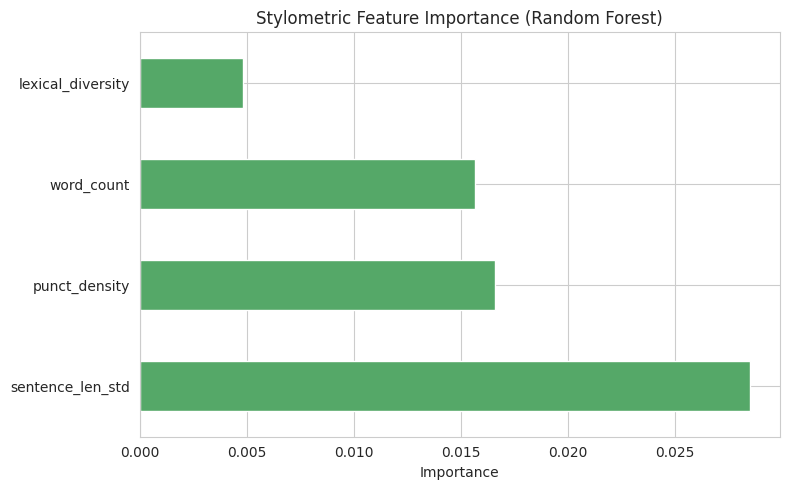

In [ ]:
plt.figure(figsize=(8, 5))
style_importance.plot(kind="barh", color="#55A868")
plt.title("Stylometric Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("chart_feature_importance.png", dpi=150)
plt.show()

## Try it on a sample

In [ ]:
def word_count_fn(text):
    return len(text.split())

def predict_sample(text):
    tfidf_vec = vectorizer.transform([text])
    style_vec = scaler.transform(pd.DataFrame([{
        "word_count": word_count_fn(text),
        "sentence_len_std": sentence_length_std(text),
        "lexical_diversity": lexical_diversity(text),
        "punct_density": punctuation_density(text),
    }])[STYLE_FEATURES])
    combined = hstack([tfidf_vec, csr_matrix(style_vec)])

    nb_result = nb_model.predict(tfidf_vec)[0]
    lr_result = lr_model.predict(combined)[0]
    rf_result = rf_model.predict(combined)[0]

    label_map = {0: "Human", 1: "AI"}
    return {
        "Naive Bayes": label_map[nb_result],
        "Logistic Regression": label_map[lr_result],
        "Random Forest": label_map[rf_result],
    }

sample_text = X_text_test.iloc[0]
print(sample_text[:200], "...\n")
print("Actual:", "AI" if y_test.iloc[0] == 1 else "Human")
print("Predictions:", predict_sample(sample_text))

The day today need of your own car may not be ac needed ac you think. Car caren't ac nice ac they seem to be. First of all they cause CMG and pollution. But people cay that not driving themselves IC a ...

Actual: Human
Predictions: {'Naive Bayes': 'Human', 'Logistic Regression': 'Human', 'Random Forest': 'Human'}


## Save everything

In [ ]:
comparison_df.to_csv("table_model_comparison.csv")
style_importance.to_frame("importance").to_csv("table_style_feature_importance.csv")

joblib.dump(nb_model, "nb_model.pkl", compress=3)
joblib.dump(lr_model, "lr_model.pkl", compress=3)
joblib.dump(rf_model, "rf_model.pkl", compress=3)
joblib.dump(vectorizer, "tfidf_vectorizer.pkl", compress=3)
joblib.dump(scaler, "style_scaler.pkl", compress=3)

print("Saved all models, scaler, vectorizer, and tables.")

Saved all models, scaler, vectorizer, and tables.


In [ ]:
from google.colab import files

files_to_download = [
    "chart_class_balance.png",
    "chart_length_distribution.png",
    "chart_sentence_stats.png",
    "chart_lexical_diversity.png",
    "chart_model_comparison.png",
    "chart_confusion_matrix.png",
    "chart_feature_importance.png",
    "table_model_comparison.csv",
    "table_style_feature_importance.csv",
    "nb_model.pkl",
    "lr_model.pkl",
    "rf_model.pkl",
    "tfidf_vectorizer.pkl",
    "style_scaler.pkl",
]

for fname in files_to_download:
    files.download(fname)

print(f"Downloaded {len(files_to_download)} files.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded 14 files.


In [ ]:
from google.colab import files
files.download('lr_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>